In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('results.csv')

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor

# 1. 데이터 불러오기
df = pd.read_csv("results.csv")

# 2. 절댓값 기반 파생 변수 생성
df['KDA_diff'] = abs(df['p1KDA'] - df['p2KDA'])
df['KP_diff'] = abs(df['p1KP'] - df['p2KP'])
df['GPM_diff'] = abs(df['p1GPM'] - df['p2GPM'])
df['Vision_diff'] = abs(df['p1Vision'] - df['p2Vision'])
df['WinRate_diff'] = abs(df['p1WinRate'] - df['p2WinRate'])

# 3. Lane 조합 (순서 무관)
df['Lane_combo'] = df.apply(lambda row: f"Lane_{min(row['p1Lane'], row['p2Lane'])}_{max(row['p1Lane'], row['p2Lane'])}", axis=1)
df = pd.get_dummies(df, columns=['Lane_combo'])

# 4. 문자열 컬럼 제거
drop_cols = ['p1Name', 'p1Tag', 'p2Name', 'p2Tag', 'Lane_combo']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# 5. 특성과 타겟 분리
X = df.drop(columns=['totalWinRate'])
y = df['totalWinRate']

# 6. 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 7. 모델 구성 및 튜닝
models = {
    'RandomForest': GridSearchCV(RandomForestRegressor(random_state=42),
        param_grid={'n_estimators': [50, 100], 'max_depth': [None, 10]}, cv=3, n_jobs=-1),
    'Ridge': GridSearchCV(Ridge(),
        param_grid={'alpha': [0.1, 1.0, 10.0]}, cv=3, n_jobs=-1),
    'SVR': GridSearchCV(SVR(),
        param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}, cv=3, n_jobs=-1),
    'XGBoost': GridSearchCV(XGBRegressor(random_state=42, verbosity=0),
        param_grid={'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]}, cv=3, n_jobs=-1)
}

# 8. 학습 및 평가
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'best_params': model.best_params_,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

# 9. 결과 출력
import pprint
pprint.pprint(results)

{'RandomForest': {'MAE': 10.158678203931931,
                  'R2': 0.17313337312229005,
                  'RMSE': np.float64(12.834635740641382),
                  'best_params': {'max_depth': 10, 'n_estimators': 100}},
 'Ridge': {'MAE': 9.940483561140946,
           'R2': 0.20293393888263422,
           'RMSE': np.float64(12.60123103975796),
           'best_params': {'alpha': 0.1}},
 'SVR': {'MAE': 10.745066728938093,
         'R2': 0.07654805360422101,
         'RMSE': np.float64(13.563537302303324),
         'best_params': {'C': 10, 'gamma': 'scale'}},
 'XGBoost': {'MAE': 10.163379818515017,
             'R2': 0.17039269933627565,
             'RMSE': np.float64(12.855888533529342),
             'best_params': {'learning_rate': 0.1,
                             'max_depth': 3,
                             'n_estimators': 50}}}


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PyTorch Dataset 정의
class WinRateDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X_train_, X_test_, y_train_, y_test_ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

train_dataset = WinRateDataset(X_train_, y_train_)
test_dataset = WinRateDataset(X_test_, y_test_)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. 간단한 MLP 모델 정의
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

# 4. 모델 초기화 및 학습
model = MLPRegressor(input_dim=X.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프
for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# 6. 예측값 추출
model.eval()
with torch.no_grad():
    y_pred_nn = model(torch.tensor(X_test_, dtype=torch.float32)).numpy().flatten()

# 7. 기존 모델들과 앙상블 (예: Ridge + XGBoost + MLP 평균)
y_pred_ridge = models['Ridge'].predict(X_test)
y_pred_xgb = models['XGBoost'].predict(X_test)

ensemble_pred = (y_pred_ridge + y_pred_xgb + y_pred_nn) / 3

# 8. 평가
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("앙상블 MAE:", mean_absolute_error(y_test, ensemble_pred))
print("앙상블 RMSE:", np.sqrt(mean_squared_error(y_test, ensemble_pred)))
print("앙상블 R2:", r2_score(y_test, ensemble_pred))


앙상블 MAE: 9.923877289208903
앙상블 RMSE: 12.591301111734728
앙상블 R2: 0.20418964002921147


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 데이터 로딩 및 준비 (이전과 동일)
df = pd.read_csv("results.csv")

# 파생 변수
df['KDA_diff'] = abs(df['p1KDA'] - df['p2KDA'])
df['KP_diff'] = abs(df['p1KP'] - df['p2KP'])
df['GPM_diff'] = abs(df['p1GPM'] - df['p2GPM'])
df['Vision_diff'] = abs(df['p1Vision'] - df['p2Vision'])
df['WinRate_diff'] = abs(df['p1WinRate'] - df['p2WinRate'])
df['Lane_combo'] = df.apply(lambda row: f"Lane_{min(row['p1Lane'], row['p2Lane'])}_{max(row['p1Lane'], row['p2Lane'])}", axis=1)
df = pd.get_dummies(df, columns=['Lane_combo'])
drop_cols = ['p1Name', 'p1Tag', 'p2Name', 'p2Tag', 'Lane_combo']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

X = df.drop(columns=['totalWinRate'])
y = df['totalWinRate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 실험 구성
experiments = {
    "baseline (no scaling)": Pipeline([
        ("model", Ridge(alpha=0.1))
    ]),
    "standard scaling": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.1))
    ]),
    "minmax scaling": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", Ridge(alpha=0.1))
    ]),
    "standard + selectKBest": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=5)),
        ("model", Ridge(alpha=0.1))
    ]),
    "standard + RFE": Pipeline([
        ("scaler", StandardScaler()),
        ("select", RFE(Ridge(alpha=0.1), n_features_to_select=5)),
        ("model", Ridge(alpha=0.1))
    ]),
}

# 결과 저장
results = {}

for name, pipeline in experiments.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

import pprint
pprint.pprint(results)


{'baseline (no scaling)': {'MAE': 9.940483561140946,
                           'R2': 0.20293393888263422,
                           'RMSE': np.float64(12.60123103975796)},
 'minmax scaling': {'MAE': 9.943409774801417,
                    'R2': 0.20266598789749823,
                    'RMSE': np.float64(12.60334894987327)},
 'standard + RFE': {'MAE': 10.130301676115364,
                    'R2': 0.17370070105885393,
                    'RMSE': np.float64(12.830231948913704)},
 'standard + selectKBest': {'MAE': 10.323272951972246,
                            'R2': 0.14366476094742786,
                            'RMSE': np.float64(13.061339666277956)},
 'standard scaling': {'MAE': 9.94188571412639,
                      'R2': 0.20268629472053235,
                      'RMSE': np.float64(12.603188455273482)}}


In [12]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pprint

# 세밀하고 넓은 파라미터 탐색
param_grids = {
    'Ridge': {
        'model': Ridge(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1, 0.2]
        }
    }
}

results = {}

# 하이퍼파라미터 튜닝 및 평가
for name, config in param_grids.items():
    print(f"\n🔍 Tuning {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, n_jobs=-1)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    results[name] = {
        'best_params': grid.best_params_,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

pprint.pprint(results)



🔍 Tuning Ridge...

🔍 Tuning RandomForest...

🔍 Tuning XGBoost...
{'RandomForest': {'MAE': 10.248473528489145,
                  'R2': 0.15948130359371893,
                  'RMSE': np.float64(12.940155784100552),
                  'best_params': {'max_depth': 5,
                                  'min_samples_split': 5,
                                  'n_estimators': 300}},
 'Ridge': {'MAE': 10.008663268512107,
           'R2': 0.19184486195934158,
           'RMSE': np.float64(12.688584751110657),
           'best_params': {'alpha': 100}},
 'XGBoost': {'MAE': 10.163379818515017,
             'R2': 0.17039269933627565,
             'RMSE': np.float64(12.855888533529342),
             'best_params': {'learning_rate': 0.1,
                             'max_depth': 3,
                             'n_estimators': 50}}}


In [13]:
param_grids_improved = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [300, 500, 700],
            'max_depth': [10, 15, 20, None],  # 더 깊은 트리 탐색
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 500],  # 더 많은 트리
            'max_depth': [3, 5, 7],  # 트리의 깊이 증가
            'learning_rate': [0.01, 0.05, 0.1, 0.2]  # 더 작은 학습률
        }
    }
}

results_improved = {}

# 모델 학습 및 성능 평가
for name, config in param_grids_improved.items():
    print(f"\n🔍 Tuning {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, n_jobs=-1)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    results_improved[name] = {
        'best_params': grid.best_params_,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

pprint.pprint(results_improved)


🔍 Tuning RandomForest...

🔍 Tuning XGBoost...
{'RandomForest': {'MAE': 10.19037167368089,
                  'R2': 0.1687984631432704,
                  'RMSE': np.float64(12.86823502920593),
                  'best_params': {'max_depth': 10,
                                  'min_samples_split': 2,
                                  'n_estimators': 500}},
 'XGBoost': {'MAE': 10.146461951846169,
             'R2': 0.17285370906833553,
             'RMSE': np.float64(12.836806031892124),
             'best_params': {'learning_rate': 0.05,
                             'max_depth': 3,
                             'n_estimators': 100}}}


### Voting Classifier (Soft Voting)

In [16]:
from sklearn.ensemble import VotingRegressor

# Ridge 추가한 Soft Voting Regressor
voting_model_with_ridge = VotingRegressor(estimators=[
    ('RandomForest', RandomForestRegressor(random_state=42, max_depth=10, n_estimators=500)),
    ('XGBoost', XGBRegressor(random_state=42, learning_rate=0.05, max_depth=3, n_estimators=100)),
    ('Ridge', Ridge(alpha=100))  # Ridge 모델 추가
])

# 모델 학습 및 예측
voting_model_with_ridge.fit(X_train, y_train)
y_pred_voting_ridge = voting_model_with_ridge.predict(X_test)

# 성능 평가
voting_results_ridge = {
    'MAE': mean_absolute_error(y_test, y_pred_voting_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_voting_ridge)),
    'R2': r2_score(y_test, y_pred_voting_ridge)
}

print("Voting Regressor with Ridge Performance:")
print(voting_results_ridge)

Voting Regressor with Ridge Performance:
{'MAE': 10.074419751435736, 'RMSE': np.float64(12.732649833888672), 'R2': 0.18622197183212374}


### Stackingg Regressor

In [18]:
from sklearn.ensemble import StackingRegressor


# Ridge 모델을 포함한 Stacking Regressor
stacking_model_with_ridge = StackingRegressor(
    estimators=[
        ('RandomForest', RandomForestRegressor(random_state=42, max_depth=10, n_estimators=500)),
        ('XGBoost', XGBRegressor(random_state=42, learning_rate=0.05, max_depth=3, n_estimators=100)),
        ('Ridge', Ridge(alpha=100))  # Ridge 모델 추가
    ],
    final_estimator=Ridge(alpha=100)  # 메타 모델로 Ridge 사용
)

# 모델 학습 및 예측
stacking_model_with_ridge.fit(X_train, y_train)
y_pred_stacking_ridge = stacking_model_with_ridge.predict(X_test)

# 성능 평가
stacking_results_ridge = {
    'MAE': mean_absolute_error(y_test, y_pred_stacking_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_stacking_ridge)),
    'R2': r2_score(y_test, y_pred_stacking_ridge)
}

print("Stacking Regressor with Ridge Performance:")
print(stacking_results_ridge)

Stacking Regressor with Ridge Performance:
{'MAE': 10.032347258409777, 'RMSE': np.float64(12.692399686222034), 'R2': 0.19135883094066442}


#### AdaBoost Regressor 추가

In [20]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# AdaBoost 모델 추가 (estimator 사용)
adaboost_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),  # 기본 트리 모델을 사용
    n_estimators=100, random_state=42
)

# 모델 학습 및 예측
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

# 성능 평가
adaboost_results = {
    'MAE': mean_absolute_error(y_test, y_pred_adaboost),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_adaboost)),
    'R2': r2_score(y_test, y_pred_adaboost)
}

print("AdaBoost Regressor Performance:")
print(adaboost_results)


AdaBoost Regressor Performance:
{'MAE': 10.345430677237466, 'RMSE': np.float64(13.066508407400981), 'R2': 0.14298687474898542}


#### GradientBoosting Regressor 추가

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# GradientBoosting 모델 추가
gradientboosting_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)

# 모델 학습 및 예측
gradientboosting_model.fit(X_train, y_train)
y_pred_gradientboosting = gradientboosting_model.predict(X_test)

# 성능 평가
gradientboosting_results = {
    'MAE': mean_absolute_error(y_test, y_pred_gradientboosting),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gradientboosting)),
    'R2': r2_score(y_test, y_pred_gradientboosting)
}

print("GradientBoosting Regressor Performance:")
print(gradientboosting_results)


GradientBoosting Regressor Performance:
{'MAE': 10.152018117337404, 'RMSE': np.float64(12.858516291085701), 'R2': 0.1700535194117878}


#### 앙상블 성능 비교

In [23]:
# Voting Regressor에 AdaBoost, GradientBoosting 포함
voting_model_with_all = VotingRegressor(estimators=[
    ('RandomForest', RandomForestRegressor(random_state=42, max_depth=10, n_estimators=500)),
    ('XGBoost', XGBRegressor(random_state=42, learning_rate=0.05, max_depth=3, n_estimators=100)),
    ('Ridge', Ridge(alpha=100)),
    ('AdaBoost', AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=100)),
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3))
])

# 모델 학습 및 예측
voting_model_with_all.fit(X_train, y_train)
y_pred_voting_all = voting_model_with_all.predict(X_test)

# 성능 평가
voting_results_all = {
    'MAE': mean_absolute_error(y_test, y_pred_voting_all),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_voting_all)),
    'R2': r2_score(y_test, y_pred_voting_all)
}

print("Voting Regressor with All Models Performance:")
print(voting_results_all)


Voting Regressor with All Models Performance:
{'MAE': 10.112126360034736, 'RMSE': np.float64(12.793470498587928), 'R2': 0.17842897780903388}


In [24]:
# Stacking Regressor에 모든 모델 추가
stacking_model_with_all = StackingRegressor(
    estimators=[
        ('RandomForest', RandomForestRegressor(random_state=42, max_depth=10, n_estimators=500)),
        ('XGBoost', XGBRegressor(random_state=42, learning_rate=0.05, max_depth=3, n_estimators=100)),
        ('Ridge', Ridge(alpha=100)),
        ('AdaBoost', AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=100)),
        ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3))
    ],
    final_estimator=Ridge(alpha=100)  # 메타 모델로 Ridge 사용
)

# 모델 학습 및 예측
stacking_model_with_all.fit(X_train, y_train)
y_pred_stacking_all = stacking_model_with_all.predict(X_test)

# 성능 평가
stacking_results_all = {
    'MAE': mean_absolute_error(y_test, y_pred_stacking_all),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_stacking_all)),
    'R2': r2_score(y_test, y_pred_stacking_all)
}

print("Stacking Regressor with All Models Performance:")
print(stacking_results_all)


Stacking Regressor with All Models Performance:
{'MAE': 10.034130747198509, 'RMSE': np.float64(12.69223622579945), 'R2': 0.19137965914956556}


In [25]:
import pickle
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 데이터 불러오기 (예시: df 데이터프레임이 이미 준비되어 있다고 가정)
X = df.drop(columns=['totalWinRate'])
y = df['totalWinRate']

# 학습용 데이터와 테스트용 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 기본 모델 정의
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)),
    ('svr', SVR(C=10, gamma='scale')),
    ('xgb', XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42))
]

# Stacking Regressor 정의
stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=100)
)

# 모델 훈련
stacking_model.fit(X_train, y_train)

# 모델 성능 평가
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = stacking_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Stacking Model Performance:")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

# 모델을 파일로 저장하기
model_filename = 'stacking_ridge_model.pkl'

# pickle을 사용해 모델을 저장
with open(model_filename, 'wb') as model_file:
    pickle.dump(stacking_model, model_file)

print(f"Model has been saved to {model_filename}")


Stacking Model Performance:
MAE: 10.11803155077277
RMSE: 12.81917823553691
R2: 0.1751238617862273
Model has been saved to stacking_ridge_model.pkl


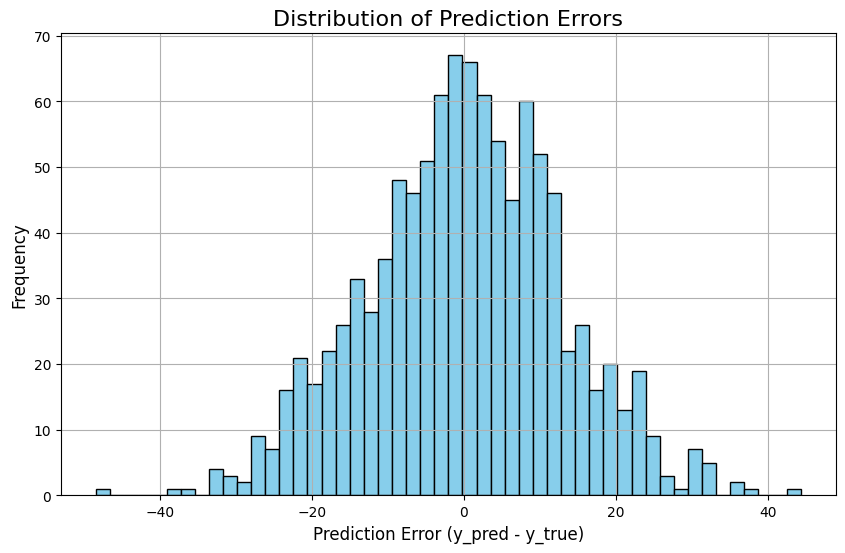

In [28]:
# 예측값과 실제값 계산 (이 부분은 모델이 학습된 후 예측값을 얻는 코드입니다)
y_pred = stacking_model.predict(X_test)  # 예시로 stacking 모델을 사용
y_true = y_test  # 실제값은 y_test로 지정

# 예측값과 실제값의 차이 (오차) 계산
prediction_errors = y_pred - y_true

# 시각화: 오차 분포
plt.figure(figsize=(10, 6))
plt.hist(prediction_errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Errors', fontsize=16)
plt.xlabel('Prediction Error (y_pred - y_true)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. 데이터 불러오기 (예시로 'df' 데이터프레임 사용)
# df = pd.read_csv("data.csv")

# 2. 특성과 타겟 분리
X = df.drop(columns=['totalWinRate'])
y = df['totalWinRate']

# 3. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 기본 모델들 정의
base_learners = [
    ('rf', RandomForestRegressor(random_state=42)),
    ('xgb', XGBRegressor(random_state=42, verbosity=0)),
    ('ridge', Ridge())
]

# 5. Stacking Regressor 설정
stacking_regressor = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge()
)

# 6. Stacking Regressor 모델 학습
stacking_regressor.fit(X_train, y_train)

# 7. 예측
y_pred = stacking_regressor.predict(X_test)

# 8. 성능 평가
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

# 9. 하이퍼파라미터 튜닝 (예시로 RandomForest와 XGBoost에 대한 파라미터 튜닝)
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 10, 15],
    'xgb__n_estimators': [50, 100, 150],
    'xgb__learning_rate': [0.01, 0.05, 0.1]
}

# GridSearchCV 사용하여 파라미터 튜닝
grid_search = GridSearchCV(
    stacking_regressor, param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터와 성능 출력
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print(f"Best MAE: {best_mae}")
print(f"Best RMSE: {best_rmse}")
print(f"Best R2: {best_r2}")


MAE: 9.969834253006113
RMSE: 12.638901641503649
R2: 0.19816125620869607


In [5]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Base estimators
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbosity=0, random_state=42)),
    ('ridge', Ridge(alpha=100))
]

# 2. Final estimator
final_estimator = Ridge(alpha=10)

# 3. Stacking with passthrough
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    passthrough=True,
    n_jobs=-1
)

# 4. Fit and Predict
stacking_model.fit(X_train, y_train)
y_pred = stacking_model.predict(X_test)

# 5. Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Stacking with passthrough Performance:")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")


Stacking with passthrough Performance:
MAE: 10.001271509462924
RMSE: 12.671796485865464
R2: 0.19398198717678528
